# In many dimensions the gap shrinks

Put the query at the center of the cube whose corners are $(\pm 1, \pm 1, \ldots, \pm 1)$. Every corner has squared distance

$$
1^2 + 1^2 + \cdots + 1^2 = d
$$

All $2^d$ corners are equally far. k-NN has no nearest corner. The neighborhood is the entire set, and the vote is just the global count.

Move the query a little, to $(1/2,\ 0,\ \ldots,\ 0)$, so the tie breaks. For a corner $c$ with coordinates $\pm 1$,

$$
\|q - c\|^2 = \left(\frac{1}{2} - c_1\right)^2 + (d - 1)
$$

If $c_1 = 1$,

$$
\left(\frac{1}{2} - 1\right)^2 + d - 1 = d - \frac{3}{4}
$$

If $c_1 = -1$,

$$
\left(\frac{1}{2} + 1\right)^2 + d - 1 = d + \frac{5}{4}
$$

The two families differ by

$$
\left(d + \frac{5}{4}\right) - \left(d - \frac{3}{4}\right) = 2
$$

The difference is $2$ no matter how large $d$ is. The nearer family sits at $d - 3/4$, which does grow. The relative gap is

$$
\frac{2}{d - 3/4} = \frac{8}{4d - 3}
$$

At $d = 2$ that fraction is $8/5$. At $d = 10$ it is $8/37$. The corners are still ranked, but the winner is only a little nearer than the loser. A neighborhood defined by "much closer than the others" becomes hard to find.


In [1]:
# The squared-distance gap stays 2. Its share of the nearer distance falls.
from fractions import Fraction

def nearer(d):
    return d - Fraction(3, 4)

def farther(d):
    return d + Fraction(5, 4)

def relative(d):
    return Fraction(8, 4 * d - 3)

assert farther(2) - nearer(2) == 2
assert farther(10) - nearer(10) == 2
assert relative(2) == Fraction(8, 5)
assert relative(10) == Fraction(8, 37)
assert relative(10) < relative(2)
print("d=2", relative(2), "d=10", relative(10))


d=2 8/5 d=10 8/37


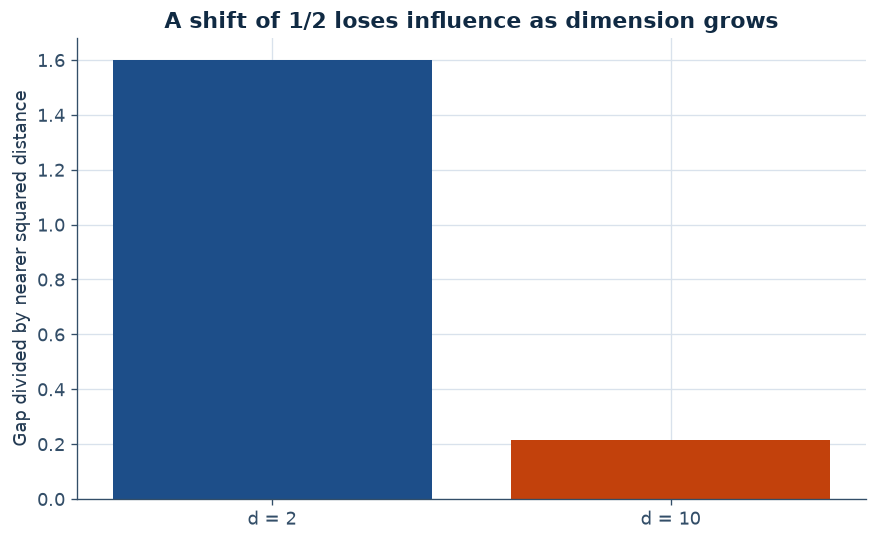

In [2]:
import matplotlib.pyplot as plt

# Quiet page. Busy is green, quiet is clay, and today is blue.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.4),
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
    "savefig.facecolor": "white",
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"

# The same absolute gap is a smaller fraction of the distance in d = 10.
fig, ax = plt.subplots(constrained_layout=True)
ax.bar(["d = 2", "d = 10"], [8 / 5, 8 / 37], color=[BLUE, CLAY])
ax.set_ylabel("Gap divided by nearer squared distance")
ax.set_title("A shift of 1/2 loses influence as dimension grows")


## A pitfall

This does not say that two genuinely different points become the same point. If every coordinate gap stays large, the distance stays large. The shrinking object is the relative advantage of the winner over the rest, when each new coordinate adds a similar squared gap to everybody.

## What to carry forward

From the center of the cube, every corner ties. Shifted by $1/2$ in one coordinate, the squared distances differ by $2$, and that gap is $8/5$ of the nearer distance when $d = 2$, but only $8/37$ when $d = 10$.
